Classification Using Artificial Neural Networks with Hyperparameter Tuning on Alphabets Data

1. Data Exploration and Preprocessing
●	Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.
●	Execute necessary data preprocessing steps including data normalization, managing missing values.

In [1]:
# Loading the dataset

import pandas as pd

df = pd.read_csv(r'Alphabets_data.csv')


In [3]:
# Displaying the basic info

print (df.info()) # Summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB
None


In [7]:
print (df.head()) # Viewing first 5 rows

  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  


In [9]:
# Get unique classes

print ('Unique classes:', df['letter'].unique())

Unique classes: ['T' 'I' 'D' 'N' 'G' 'S' 'B' 'A' 'J' 'M' 'X' 'O' 'R' 'F' 'C' 'H' 'W' 'L'
 'P' 'E' 'V' 'Y' 'Q' 'U' 'K' 'Z']


In [13]:
print ('Unique classes - value counts:', df['letter'].value_counts())

Unique classes: letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


In [15]:
print ('Number of unique classes:', df['letter'].nunique())

Unique classes: 26


In [27]:
print ('Unique classes sorted:', sorted(df['letter'].unique()))

Unique classes sorted: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [25]:
# Check for missing values

print (df.isnull().sum())

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64


In [29]:
# Summary statistics

print (df.describe())


               xbox          ybox         width       height         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean       4.023550      7.035500      5.121850      5.37245      3.505850   
std        1.913212      3.304555      2.014573      2.26139      2.190458   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%        3.000000      5.000000      4.000000      4.00000      2.000000   
50%        4.000000      7.000000      5.000000      6.00000      3.000000   
75%        5.000000      9.000000      6.000000      7.00000      5.000000   
max       15.000000     15.000000     15.000000     15.00000     15.000000   

               xbar          ybar         x2bar         y2bar         xybar  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       6.897600      7.500450      4.628600      5.178650      8.282050   
std        2.026035      2.325354      2.699968      2.38082

In [32]:
print ("No. of features:", {len(df.columns)-1}) # Exclude the letter column

No. of features: {16}


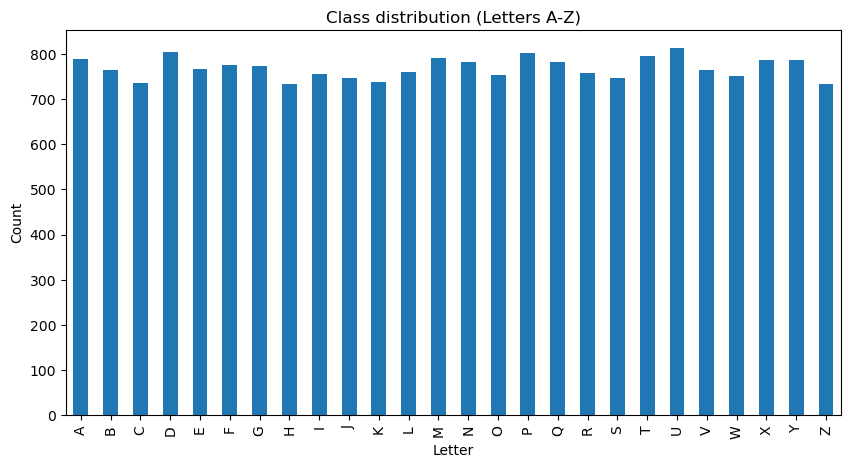

In [36]:
# Visualize class distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df['letter'].value_counts().sort_index().plot(kind='bar')
plt.title("Class distribution (Letters A-Z)")
plt.xlabel('Letter')
plt.ylabel('Count')
plt.show()


# Data Preprocessing

In [ ]:
# No missing values to handle

In [238]:
# Separate Features (X) and Labels (Y) data


X= df.iloc[:,1:16]
Y= df.iloc[:,0]


# X = dataset[:,0:8]
# Y = dataset[:,8]

In [240]:
X

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge
0,0.133333,0.533333,0.200000,0.333333,0.066667,0.533333,0.866667,0.000000,0.400000,0.400000,0.666667,0.533333,0.000000,0.533333,0.000000
1,0.333333,0.800000,0.200000,0.466667,0.133333,0.666667,0.333333,0.333333,0.266667,0.866667,0.200000,0.600000,0.133333,0.533333,0.266667
2,0.266667,0.733333,0.400000,0.533333,0.400000,0.666667,0.400000,0.133333,0.400000,0.666667,0.200000,0.466667,0.200000,0.466667,0.200000
3,0.466667,0.733333,0.400000,0.400000,0.200000,0.333333,0.600000,0.266667,0.400000,0.266667,0.266667,0.666667,0.400000,0.666667,0.133333
4,0.133333,0.066667,0.200000,0.066667,0.066667,0.533333,0.400000,0.400000,0.400000,0.400000,0.333333,0.600000,0.066667,0.466667,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.133333,0.133333,0.200000,0.200000,0.133333,0.466667,0.466667,0.466667,0.400000,0.400000,0.400000,0.266667,0.133333,0.533333,0.200000
19996,0.466667,0.666667,0.533333,0.533333,0.266667,0.266667,0.533333,0.400000,0.600000,0.800000,0.600000,0.866667,0.133333,0.600000,0.200000
19997,0.400000,0.600000,0.400000,0.466667,0.333333,0.400000,0.733333,0.200000,0.466667,0.733333,0.600000,0.333333,0.133333,0.800000,0.133333
19998,0.133333,0.200000,0.266667,0.133333,0.066667,0.533333,0.466667,0.133333,0.400000,0.666667,0.400000,0.533333,0.066667,0.600000,0.333333


In [242]:
Y

0        T
1        I
2        D
3        N
4        G
        ..
19995    D
19996    C
19997    T
19998    S
19999    A
Name: letter, Length: 20000, dtype: object

In [244]:
print (type(X))
print (type(Y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [246]:
# Standardization


from sklearn.preprocessing import StandardScaler
a=StandardScaler()
a.fit(X)
X_standardized = a.transform(X)

In [248]:
# Label encoding of target variable
import numpy as np

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y_encoded = le.fit_transform(Y)

print (f"\n Encoded labels : {np.unique(y_encoded)}")


 Encoded labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [250]:
# Train-Test split, 80/20

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,y_encoded, test_size=0.2,random_state=42)

print (f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print (f"Y Train shape : {Y_train.shape}, Y Test shape: {Y_test.shape}")

Train shape: (16000, 15), Test shape: (4000, 15)
Y Train shape : (16000,), Y Test shape: (4000,)


In [252]:
print (type(X_train))
print (type(Y_train))
print (type(X_test))
print (type(Y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [254]:
# Convert X and y_encoded to NumPy arrays before splitting to ensure uniformity.


In [264]:
y_encoded=pd.DataFrame(y_encoded)

In [266]:
# X = np.array(X)  # Convert to NumPy array

X_train, X_test, Y_train, Y_test = train_test_split(X,y_encoded, test_size=0.2,random_state=42)

print (f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print (f"Y Train shape : {Y_train.shape}, Y Test shape: {Y_test.shape}")

Train shape: (16000, 15), Test shape: (4000, 15)
Y Train shape : (16000, 1), Y Test shape: (4000, 1)


In [268]:
print (type(X_train))
print (type(Y_train))
print (type(X_test))
print (type(Y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [270]:
X_train

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge
5894,0.266667,0.466667,0.333333,0.333333,0.266667,0.400000,0.466667,0.200000,0.466667,0.733333,0.533333,0.600000,0.200000,0.533333,0.266667
3728,0.266667,0.466667,0.400000,0.333333,0.333333,0.400000,0.533333,0.200000,0.466667,0.733333,0.533333,0.600000,0.200000,0.533333,0.266667
8958,0.200000,0.333333,0.266667,0.200000,0.200000,0.466667,0.533333,0.333333,0.333333,0.466667,0.466667,0.400000,0.333333,0.600000,0.133333
7671,0.266667,0.666667,0.400000,0.466667,0.400000,0.333333,0.466667,0.333333,0.466667,0.400000,0.400000,0.800000,0.200000,0.533333,0.400000
5999,0.266667,0.666667,0.400000,0.533333,0.266667,0.533333,0.733333,0.133333,0.200000,0.266667,0.666667,0.600000,0.200000,0.733333,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.333333,0.733333,0.266667,0.400000,0.200000,0.466667,0.466667,0.266667,0.200000,0.600000,0.400000,0.466667,0.200000,0.666667,0.533333
11964,0.200000,0.466667,0.333333,0.333333,0.266667,0.600000,0.733333,0.400000,0.266667,0.400000,0.333333,0.466667,0.133333,0.533333,0.400000
5390,0.200000,0.266667,0.400000,0.200000,0.133333,0.600000,0.400000,0.133333,0.533333,0.666667,0.200000,0.466667,0.133333,0.466667,0.200000
860,0.200000,0.533333,0.266667,0.400000,0.133333,0.466667,0.533333,0.000000,0.533333,0.933333,0.400000,0.400000,0.000000,0.533333,0.066667


In [272]:
X_test

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge
10650,0.200000,0.400000,0.333333,0.400000,0.266667,0.400000,0.466667,0.200000,0.533333,0.533333,0.400000,0.600000,0.200000,0.466667,0.466667
2041,0.266667,0.733333,0.400000,0.533333,0.533333,0.466667,0.533333,0.200000,0.333333,0.400000,0.400000,0.666667,0.400000,0.733333,0.466667
8668,0.200000,0.266667,0.333333,0.200000,0.133333,0.666667,0.133333,0.133333,0.066667,0.600000,0.133333,0.600000,0.133333,0.400000,0.133333
1114,0.133333,0.266667,0.133333,0.200000,0.133333,0.466667,0.466667,0.333333,0.466667,0.466667,0.400000,0.533333,0.133333,0.533333,0.333333
13902,0.266667,0.333333,0.333333,0.466667,0.200000,0.533333,0.466667,0.533333,0.400000,0.400000,0.466667,0.600000,0.200000,0.533333,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4073,0.266667,0.466667,0.400000,0.333333,0.466667,0.400000,0.400000,0.200000,0.133333,0.533333,0.400000,0.466667,0.200000,0.466667,0.733333
7442,0.133333,0.066667,0.200000,0.200000,0.066667,0.400000,0.800000,0.200000,0.400000,0.533333,0.733333,0.466667,0.066667,0.733333,0.066667
9999,0.333333,0.666667,0.466667,0.600000,0.266667,0.533333,0.333333,0.600000,0.533333,0.333333,0.266667,0.533333,0.200000,0.533333,0.266667
1870,0.266667,0.333333,0.333333,0.466667,0.333333,0.666667,0.733333,0.333333,0.266667,0.333333,0.533333,0.533333,0.333333,0.666667,0.600000


In [274]:
Y_train

,0
5894,4
3728,4
8958,13
7671,10
5999,21
...,...
11284,6
11964,25
5390,23
860,8


In [276]:
Y_test

,0
10650,19
2041,11
8668,0
1114,4
13902,16
...,...
4073,18
7442,19
9999,16
1870,24


In [278]:

# Calculate expected image dimensions
total_pixels = X_test.size
num_samples = len(X_test)
pixels_per_image = total_pixels // num_samples
print (f"Pixels per image: {pixels_per_image}")

# Find perfect square dimensions (if applicable)
possible_dim = int(np.sqrt(pixels_per_image))
print (f'Possible square dimensions: {possible_dim}X{possible_dim}')

Pixels per image: 15
Possible square dimensions: 3X3


In [280]:

# Calculate expected image dimensions
total_pixels = X_train.size
num_samples = len(X_train)
pixels_per_image = total_pixels // num_samples
print (f"Pixels per image: {pixels_per_image}")

# Find perfect square dimensions (if applicable)
possible_dim = int(np.sqrt(pixels_per_image))
print (f'Possible square dimensions: {possible_dim}X{possible_dim}')

Pixels per image: 15
Possible square dimensions: 3X3


In [282]:
print(X_test.size)
print (X_train.size)

60000
240000


In [284]:
print(Y_test.size)
print (Y_train.size)

4000
16000


In [286]:
print(len(X_test))
print (len(X_train))

4000
16000


In [288]:
print(len(Y_test))
print (len(Y_train))

4000
16000


Significance of Reshaping Flattened Images for ANN

1. Preserving Spatial Structure (Critical for Image Data)
Problem: When images are stored as flattened 1D arrays (e.g., 784 pixels for 28×28 images), the ANN loses all spatial context (nearby pixels, 
edges, shapes).

Solution: Reshaping to (height, width, channels) explicitly tells the model:
        # From flattened (784,) → 2D image (28, 28, 1)
        X_train = X_train.reshape(-1, 28, 28, 1)  # Grayscale (1 channel)
This maintains the original image structure, allowing the model to learn spatial hierarchies.

2. Compatibility with Advanced Layers
Flattened Data: Only works with Dense layers, which treat pixels as independent features.
        model.add(Dense(128, input_shape=(784,)))  # Ignores spatial relationships
Reshaped Data: Enables use of Convolutional Layers (CNN) that exploit local patterns:                                 
        model.add(Conv2D(32, kernel_size=(3,3), input_shape=(28,28,1)))  # Detects edges/text

3. Input Shape Requirements
ANN Expects Fixed Dimensions:

A Dense layer needs (batch_size, features).

A Conv2D layer needs (batch_size, height, width, channels).

# Incorrect (flattened):
Input shape: (784,)  # Treated as 784 independent features

# Correct (reshaped):
Input shape: (28, 28, 1)  # Treated as a 2D image


4. Impact on Model Performance
Aspect	                   Flattened Data	                            Reshaped 2D Data
Parameter Count	           High (each pixel connects to all neurons)	Lower (convolution shares weights)
Translation Invariance	   No (pixel position matters)	                Yes (filters detect patterns anywhere)
Accuracy (MNIST Example)	~95%	                                    ~99%+

5. When to Reshape
Mandatory: If using CNNs (Convolutional Neural Networks).

Optional but Helpful: For standard ANNs, reshaping can still improve interpretability of learned features.


Key Takeaway
Reshaping transforms raw pixel arrays into structured images, enabling:

Spatial feature learning (edges → shapes → letters)
Efficient parameter usage (via weight sharing in CNNs)
Higher accuracy with fewer parameters
                                 
                                 

In [321]:
# If Features Are Already Flattened (Non-Image Data)
# If X_train.shape[1] is not 1024 (32x32), then your data is likely not an image. Just ensure it's in the right shape for ANN models:

X_train = X_train.reshape(-1, X_train.shape[1])  # Keep all features
X_test = X_test.reshape(-1, X_test.shape[1])

In [ ]:
# Verify Preprocessing

In [325]:
print("Reshaped X_train shape:", X_train.shape)
print("Reshaped X_test shape:", X_test.shape)

Reshaped X_train shape: (16000, 15)
Reshaped X_test shape: (4000, 15)


# Model Implementation

In [336]:
pip install tensorflow

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Smrithi\\anaconda3\\Lib\\site-packages\\clang\\native\\libclang.dll'
Consider using the `--user` option or check the permissions.



  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached absl_py-2.2.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached grpcio-1.71.0-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached ml_dtypes-0.5.1-cp312-cp312-win_amd64.whl.metadata (22 kB)
  Using cached namex-0.0.8-py3-none-any.whl.metadata (246 bytes)
  Using cached optree-0.14

In [338]:
import tensorflow as tf

In [350]:
# Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.

# Model Implementation (Using Keras)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.optimizers import Adam




In [514]:
# Create model

model = Sequential([
    Input(shape=(15,)), # 15 features as input
    Dense(45,activation='relu'), #First hidden layer with 3 times input features
    Dense(30,activation='relu'), #Second hdden layer
    Dense(15,activation='relu'), # Third hidden layer
    Dense(26,activation='softmax') # Output layer with 26 neurons for 26 alphabets
])



In [516]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), 
             loss='sparse_categorical_crossentropy', #Correct loss for integer labels
             metrics=['accuracy'] )



In [518]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 45)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │           416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,981 (11.64 KB)

 Trainable params: 2,981 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [520]:
print (type (X_test))
print (type (Y_test))
print (type (X_train))
print (type (Y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [522]:
# Converting Y_train and Y_test into an array from dataframe

In [524]:
Y_test=np.array(Y_test)

In [526]:
Y_train = np.array(Y_train)

In [528]:
print (type(Y_test))
print (type(Y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [530]:
# Predict on test set

y_pred = model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [532]:
# Convert probabilities into class labels

y_pred_labels = np.argmax(y_pred, axis=1)
Y_test_labels = np.argmax(Y_test, axis = 1)

# Print predictions

print (f'Predicted labels: {y_pred_labels[:10]}')
print (f'Actual labels: {Y_test_labels[:10]}')

Predicted labels: [21 12 12 12 12 12 12 12 12 12]
Actual labels: [0 0 0 0 0 0 0 0 0 0]


In [534]:
# Compute Accuracy for Current Model

from sklearn.metrics import accuracy_score

# Compute Accuracy
accuracy_model = accuracy_score(Y_test_labels, y_pred_labels)

print(f'🔹 Accuracy of Current Model: {accuracy_model:.4f}')


🔹 Accuracy of Current Model: 0.0000


# Hyperparameter tuning

In [ ]:
# # Lets tune in the hyperparameters so that we can observe the impact it has on model performance.

# We will adjust-

# 1. Number of hidden layers
# 2. Neurons per hidden layer
# 3. Activation functions
# 4. Learning rate

In [395]:
# Define a function to build models with different hyperparameters

def build_model(hidden_layers=2, neurons=[68,128], activation = 'relu', learning_rate = 0.001, dropout_rate=0.3):
    model = Sequential()

# input layer
    model.add(Dense(neurons[0], activation=activation, input_shape=(15,)))

# hidden layers
    for i in range(1,hidden_layers):
        model.add(Dense(neurons[i], activation=activation))
        model.add(Dropout(dropout_rate)) # Adding dropout for regularization

# Output layer
    model.add(Dense(26,activation='softmax'))

# Compile model
    optimizer = Adam (learning_rate = learning_rate)
    model.compile(optimizer = optimizer, loss ='sparse_categorical_crossentropy', metrics = ['accuracy'])

    return model

In [398]:
# Experiment with different hyperparameters

In [400]:
# Experiment 1 : Baseline model

model1 = build_model(hidden_layers=2, neurons=[64,128], activation = 'relu', learning_rate = 0.001, dropout_rate=0.3)
history1 = model1.fit(X_train, Y_train, epochs =30, batch_size=32, validation_data=(X_test, Y_test))

# Experiment 2: More hidden layers

model2 = build_model(hidden_layers=3, neurons=[64, 128, 256], activation= 'relu', learning_rate=0.001, dropout_rate=0.3)
history2 = model2.fit(X_train, Y_train, epochs = 30, batch_size=32, validation_data=(X_test,Y_test))

# Experiment 3: Different activation (tanh)

model3 = build_model(hidden_layers=2, neurons=[64,128], activation = 'tanh', learning_rate = 0.001, dropout_rate= 0.3)
history3 = model3.fit(X_train, Y_train, epochs= 30, batch_size=32, validation_data=(X_test, Y_test))

# Experiment 4: Lowering learning rate

model4 = build_model(hidden_layers=2, neurons=[64,128],activation='relu',learning_rate=0.0005, dropout_rate = 0.3)
history4 = model4.fit(X_train, Y_train, epochs=30, batch_size=32, validation_data=(X_test, Y_test))

Epoch 1/30


C:\Users\Smrithi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2117 - loss: 2.8200 - val_accuracy: 0.5555 - val_loss: 1.5898
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5277 - loss: 1.5880 - val_accuracy: 0.6248 - val_loss: 1.2588
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6090 - loss: 1.3435 - val_accuracy: 0.6790 - val_loss: 1.1173
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6447 - loss: 1.2062 - val_accuracy: 0.7172 - val_loss: 1.0170
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6845 - loss: 1.0968 - val_accuracy: 0.7358 - val_loss: 0.9465
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6952 - loss: 1.0390 - val_accuracy: 0.7408 - val_loss: 0.8839
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7166 - loss: 0.9746 - val_accuracy: 0.7635 - val_loss: 0.8352
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7181 - loss: 0.9316 - val_accuracy: 0.7720 - val_

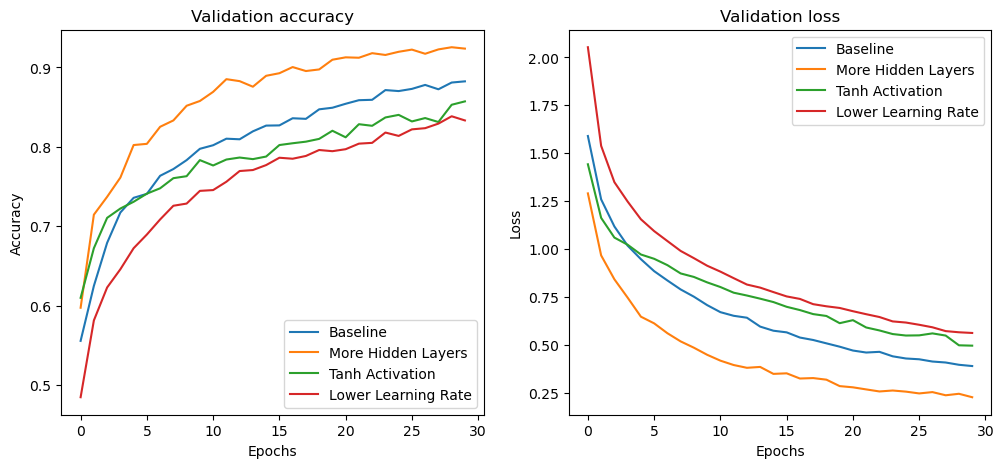

In [404]:
import matplotlib.pyplot as plt

def plot_history(histories,labels):
    plt.figure(figsize=(12,5))

# Plot accuracy
    plt.subplot(1,2,1)
    for i, history in enumerate(histories):
        plt.plot(history.history['val_accuracy'], label=labels[i])
    plt.title('Validation accuracy')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1,2,2)
    for i, history in enumerate(histories):
        plt.plot(history.history['val_loss'], label=labels[i])
    plt.title('Validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Compare experiments
plot_history(
    histories =[history1, history2, history3, history4],
    labels = ['Baseline', 'More Hidden Layers', 'Tanh Activation', 'Lower Learning Rate'])

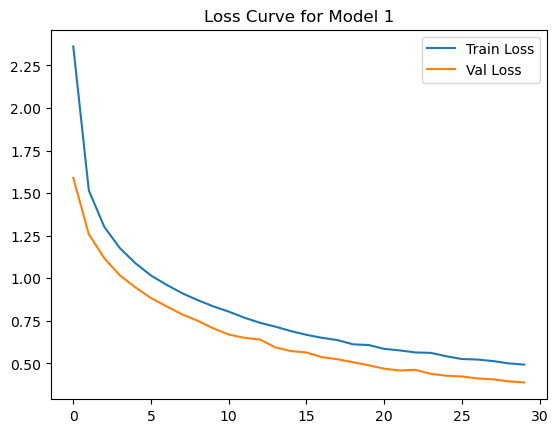

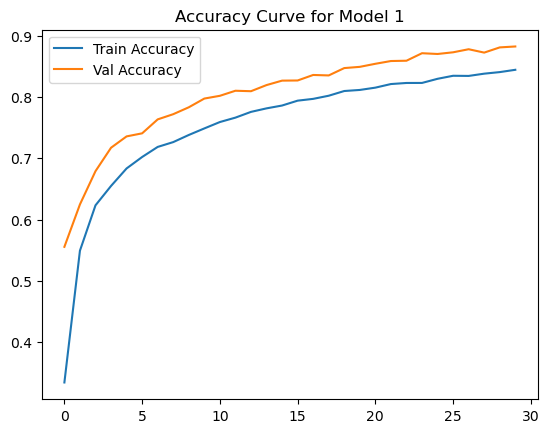

In [418]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve for Model 1')
plt.show()

# Plot training & validation accuracy
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve for Model 1')
plt.show()


In [420]:
# Get final training and validation loss & accuracy
final_train_loss = history1.history['loss'][-1]
final_val_loss = history1.history['val_loss'][-1]
final_train_acc = history1.history['accuracy'][-1]
final_val_acc = history1.history['val_accuracy'][-1]

print (f"Model 1")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Model 1
Final Training Loss: 0.4935
Final Validation Loss: 0.3883
Final Training Accuracy: 0.8444
Final Validation Accuracy: 0.8825


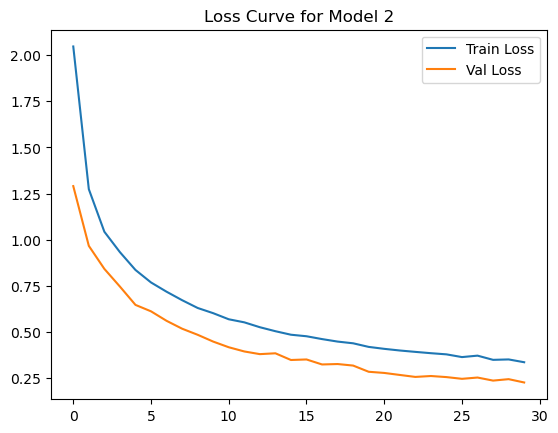

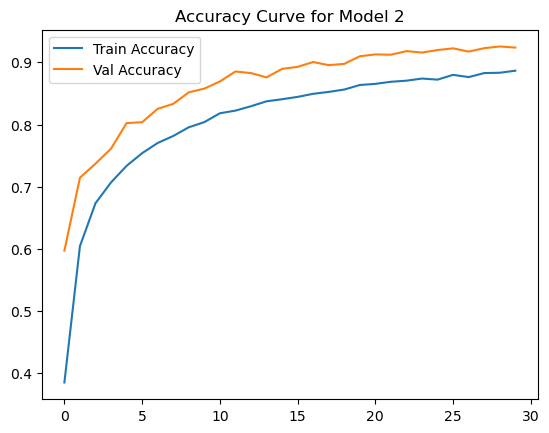

In [422]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve for Model 2')
plt.show()

# Plot training & validation accuracy
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve for Model 2')
plt.show()


In [424]:
# Get final training and validation loss & accuracy
final_train_loss = history2.history['loss'][-1]
final_val_loss = history2.history['val_loss'][-1]
final_train_acc = history2.history['accuracy'][-1]
final_val_acc = history2.history['val_accuracy'][-1]

print (f"Model 2")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Model 2
Final Training Loss: 0.3352
Final Validation Loss: 0.2254
Final Training Accuracy: 0.8866
Final Validation Accuracy: 0.9237


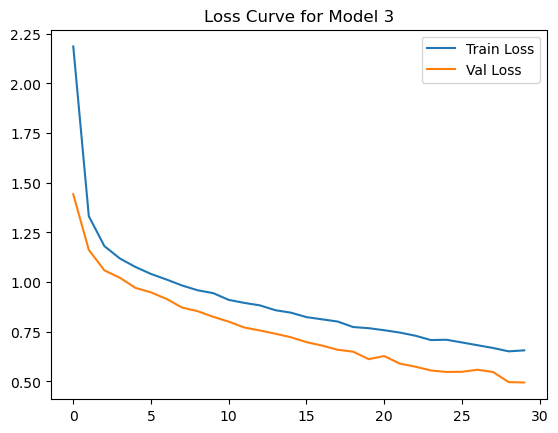

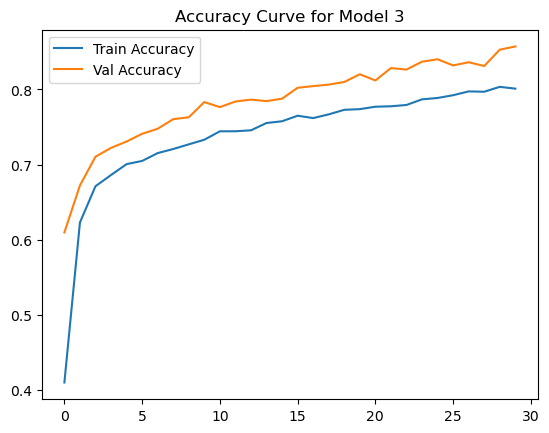

In [428]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve for Model 3')
plt.show()

# Plot training & validation accuracy
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve for Model 3')
plt.show()


In [430]:
# Get final training and validation loss & accuracy
final_train_loss = history3.history['loss'][-1]
final_val_loss = history3.history['val_loss'][-1]
final_train_acc = history3.history['accuracy'][-1]
final_val_acc = history3.history['val_accuracy'][-1]

print (f"Model 3")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Model 3
Final Training Loss: 0.6565
Final Validation Loss: 0.4948
Final Training Accuracy: 0.8011
Final Validation Accuracy: 0.8572


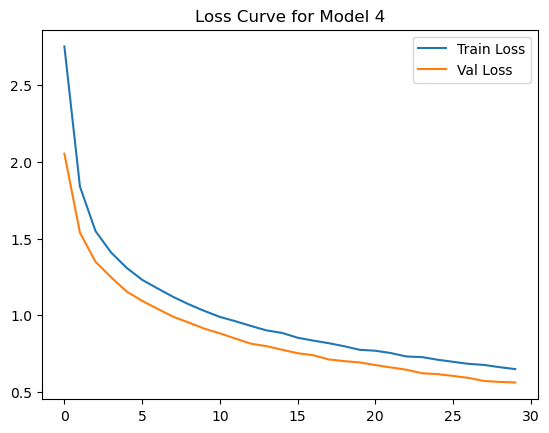

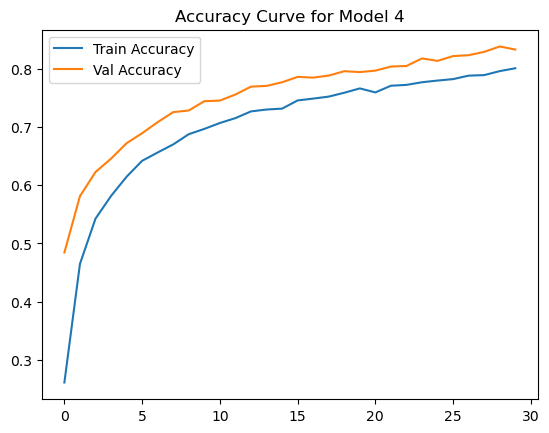

In [432]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve for Model 4')
plt.show()

# Plot training & validation accuracy
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve for Model 4')
plt.show()


In [434]:
# Get final training and validation loss & accuracy
final_train_loss = history4.history['loss'][-1]
final_val_loss = history4.history['val_loss'][-1]
final_train_acc = history4.history['accuracy'][-1]
final_val_acc = history4.history['val_accuracy'][-1]

print (f"Model 4")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Model 4
Final Training Loss: 0.6483
Final Validation Loss: 0.5611
Final Training Accuracy: 0.8011
Final Validation Accuracy: 0.8332


In [442]:
# Setting up Keras Tuner for automatic hyperparameter tuning.

!pip install keras-tuner

In [ ]:
# Define a function to build the model with tunable hyperparameters.

# Use Keras Tuner to search for the best hyperparameters.



In [458]:
# Define the model for tuning

import keras_tuner as kt
# Define model function

def build_model(hp):
    model = Sequential()
    # Use Input layer as the first layer
    model.add(Input(shape=(15,)))  # Input shape is 15 features
    
    # Add Dense layer with hyperparameter tuning
    model.add(Dense(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation=hp.Choice('activation', ['relu', 'tanh', 'sigmoid'])
    ))
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(26, activation='softmax'))  # Output layer (26 classes)

    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [460]:
from tensorflow import keras

In [ ]:
Let's break down your **Keras Tuner** code **line by line** to understand how it works.  

## **🔹 Step 1: Import Keras Tuner**

import keras_tuner as kt

- **keras_tuner** is a library that helps in **hyperparameter tuning**.  
- It allows you to **automate the process** of finding the best model configuration (e.g., number of neurons, learning rate, activation function).  
---
## **🔹 Step 2: Define the Model Function for Hyperparameter Tuning**

def build_model(hp):

- The function **`build_model(hp)`** is used by **Keras Tuner** to test different model configurations.  
- The **`hp` (Hyperparameters)** object allows you to define different values for tuning (like number of neurons, activation functions, dropout rates, etc.).  

### **🔹 Step 2.1: Define the Model Structure**

model = Sequential()

- **Creates a Sequential model**, meaning layers are added **one after another**.  

model.add(Input(shape=(15,)))  # Input shape is 15 features

- **Defines the input layer** with **15 features** (assuming your dataset has 15 input variables).  
- This is an alternative to `Dense(input_shape=(15,))`.  

### **🔹 Step 2.2: Add a Tunable Hidden Layer**

model.add(Dense(
    units=hp.Int('units_1', min_value=32, max_value=256, step=32),
    activation=hp.Choice('activation', ['relu', 'tanh', 'sigmoid'])
))

- **First Dense layer (hidden layer)** with **tunable neurons and activation function**.  
- `hp.Int('units_1', min_value=32, max_value=256, step=32)`  
  - This means **the number of neurons will be chosen from**:  
    **[32, 64, 96, 128, 160, 192, 224, 256]**.  
- `hp.Choice('activation', ['relu', 'tanh', 'sigmoid'])`  
  - **Keras Tuner will test different activation functions** (`relu`, `tanh`, `sigmoid`).  

### **🔹 Step 2.3: Add Dropout for Regularization**

model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

- **Dropout layer** helps prevent **overfitting** by randomly **turning off neurons** during training.  
- `hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)`  
  - The dropout rate is **tunable** and will be chosen from **[0.1, 0.2, 0.3, 0.4, 0.5]**.  

### **🔹 Step 2.4: Define the Output Layer**

model.add(Dense(26, activation='softmax'))  # Output layer (26 classes)

- **26 neurons** (since the output represents **26 letters A-Z**).  
- Uses **`softmax` activation** for multi-class classification.  

## **🔹 Step 3: Compile the Model with a Tunable Optimizer**

model.compile(
    optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

- **Tunable learning rate** → `hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])`  
  - Keras Tuner will **try different learning rates**: `0.001, 0.0005, 0.0001`.  
- **Loss function** → `sparse_categorical_crossentropy` (because labels are **integers**).  
- **Evaluation metric** → `accuracy`.  

## **🔹 Step 4: Set Up Keras Tuner**

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to try
    executions_per_trial=2,  # Runs per model for stability
    directory='keras_tuner_results',
    project_name='alphabet_model_tuning'
)
- **Uses Keras Tuner's `RandomSearch` algorithm**.  
- `objective='val_accuracy'` → **Tuning goal** is to maximize validation accuracy.  
- `max_trials=10` → **Tests 10 different model configurations**.  
- `executions_per_trial=2` → **Each model runs 2 times** for stability.  
- `directory='keras_tuner_results'` → Saves the tuning results in this folder.  
- `project_name='alphabet_model_tuning'` → Name of the tuning experiment.  

---

## **🔹 Summary**

Step	     Code	                      Purpose
1	    import keras_tuner as kt          Imports Keras Tuner
2	    def build_model(hp):	          Defines a function for model tuning
2.1	    model = Sequential()	          Creates a Sequential model
2.2	    model.add(Input(shape=(15,)))	  Defines input layer (15 features)
2.3	    model.add(Dense(...))	          Adds a tunable hidden layer (neurons + activation)
2.4     model.add(Dropout(...))	          Adds dropout regularization
2.5	    model.add(Dense(26, activation='softmax'))	Defines output layer (26 classes)
3	    model.compile(...)	              Sets optimizer, loss, and metrics
4	    tuner = kt.RandomSearch(...)	   Initializes Keras Tuner with Random Search
---

## **💡 Next Steps**
After defining the tuner, you need to **start the tuning process**:  

tuner.search(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_test, Y_test))

- This **trains different models** and finds the best hyperparameters.

After training, you can get the **best model**:

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


And **build the best model**:

best_model = tuner.hypermodel.build(best_hps)
best_model.summary()
---
## **🚀 Final Takeaways**
1. **Keras Tuner automates hyperparameter tuning**, finding the best model.  
2. It **tests different configurations** (neurons, activation, dropout, learning rate).  
3. The **best model can be retrieved and further trained**.  
4. **Tuning is essential** to improve model performance.  


In [464]:
# Set Up Keras Tuner
# Use RandomSearch, Hyperband, or BayesianOptimization to search for the best hyperparameters.

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to try
    executions_per_trial=2,  # Runs per model for stability
    directory='keras_tuner_results',
    project_name='alphabet_model_tuning'
)


In [466]:
# Start Hyperparameter Search
# Run the tuning process using the training data.

tuner.search(X_train, Y_train, epochs=30, validation_data=(X_test, Y_test), batch_size=32)


Trial 10 Complete [00h 02m 31s]
val_accuracy: 0.43150000274181366

Best val_accuracy So Far: 0.8462499976158142
Total elapsed time: 00h 24m 59s


In [468]:
# Get the Best Hyperparameters
# Once tuning is complete, retrieve the best hyperparameters and train the final model.

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best Number of Neurons: {best_hps.get('units_1')}")
print(f"Best Activation Function: {best_hps.get('activation')}")
print(f"Best Dropout Rate: {best_hps.get('dropout')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")


Best Number of Neurons: 256
Best Activation Function: relu
Best Dropout Rate: 0.2
Best Learning Rate: 0.001


In [470]:
# Train the Final Model
# Use the best hyperparameters to train the final model.


best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, Y_train, epochs=30, validation_data=(X_test, Y_test), batch_size=32)


Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2306 - loss: 2.9333 - val_accuracy: 0.5418 - val_loss: 1.9131
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5264 - loss: 1.8148 - val_accuracy: 0.6173 - val_loss: 1.4791
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6026 - loss: 1.4602 - val_accuracy: 0.6510 - val_loss: 1.2924
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6427 - loss: 1.3045 - val_accuracy: 0.7005 - val_loss: 1.1832
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6665 - loss: 1.2174 - val_accuracy: 0.7075 - val_loss: 1.1119
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6743 - loss: 1.1632 - val_accuracy: 0.7295 - val_loss: 1.0494
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7012 - loss: 1.0907 - val_accuracy: 0.7312 - val_loss: 1.0056
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7114 - loss: 1.0418 - val_accuracy: 0.

In [472]:
# Evaluate the Model
# After training, test it on unseen data.

test_loss, test_acc = best_model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_acc:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8499 - loss: 0.5171
Test Accuracy: 0.8453


In [ ]:
# Comparing Training & Validation Accuracy to Detect Overfitting or Underfitting
# Once your model is trained using Keras Tuner, you can compare training accuracy and validation accuracy using the history object.


# Extract Accuracy Values
# After training your model, the history object contains accuracy and loss values for both training and validation sets.

In [474]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

In [ ]:
# Compare Training vs. Validation Accuracy
# Use plots or numerical summaries to check whether the model is overfitting, underfitting, or well-generalized.

In [476]:
# Print Final Accuracy Values
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

Final Training Accuracy: 0.8254
Final Validation Accuracy: 0.8453


In [ ]:
# Check the Difference Between Training & Validation Accuracy

In [478]:
diff = abs(train_acc[-1] - val_acc[-1])
print(f"Accuracy Difference: {diff:.4f}")

Accuracy Difference: 0.0198


In [ ]:
# If diff > 0.1, overfitting (model memorizing training data but not generalizing).

# If train_acc and val_acc are both low, underfitting (model not learning well).

# If train_acc and val_acc are close and high, good fit.

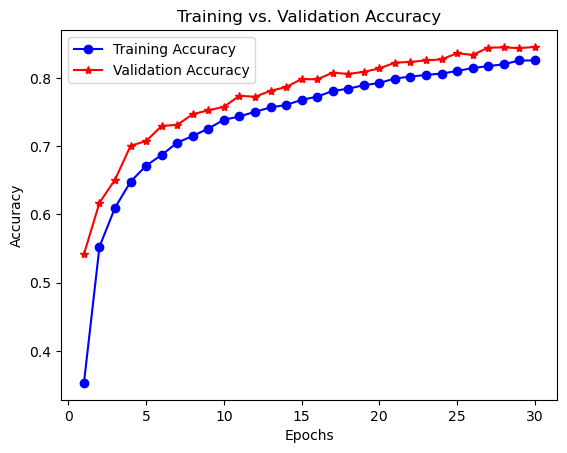

In [480]:
# Visualizing Training vs. Validation Accuracy
# If you prefer a graph, use Matplotlib:

import matplotlib.pyplot as plt

epochs = range(1, len(train_acc) + 1)

plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')
plt.show()


# Finding the Best Parameters in Model 2
# Since Model 2 gives the best accuracy, you can analyze its hyperparameters and performance metrics to understand why it performed better.¶

In [500]:
# Step 1: Extract Best Parameters from Model 2
# You can check the weights, biases, and hyperparameters used in Model 2.

# Check model summary
model2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,152 (574.82 KB)

 Trainable params: 49,050 (191.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,102 (383.21 KB)

In [ ]:
# This shows the number of layers, neurons per layer, activation functions, and trainable parameters.

In [ ]:
# Comparing Model 2 (Best Manual Model) with Keras Tuned Model 
# To compare Model 2 (your best manually tuned model) with the best model from Keras Tuner, 
# you need to check their hyperparameters, accuracy, and loss values...

In [ ]:
# The below steps are already done so not repeating
# Step 2: Retrieve Best Hyperparameters from Keras Tuner
# Step 3: Train the Best Tuned Model

In [502]:
# Step 4: Compare Model 2 vs. Best Tuned Model

# Now, compare training & validation accuracy and loss for both models.

# 1️⃣ Compare Final Accuracy & Loss

models = [history2, history]
model_names = ["Manual Model 2", "Keras Tuned Model"]

for i, history in enumerate(models):
    print(f"{model_names[i]} - Final Train Accuracy: {history.history['accuracy'][-1]:.4f}, Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"{model_names[i]} - Final Train Loss: {history.history['loss'][-1]:.4f}, Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print("-" * 50)


Manual Model 2 - Final Train Accuracy: 0.8866, Validation Accuracy: 0.9237
Manual Model 2 - Final Train Loss: 0.3352, Validation Loss: 0.2254
--------------------------------------------------
Keras Tuned Model - Final Train Accuracy: 0.8254, Validation Accuracy: 0.8453
Keras Tuned Model - Final Train Loss: 0.5786, Validation Loss: 0.5259
--------------------------------------------------


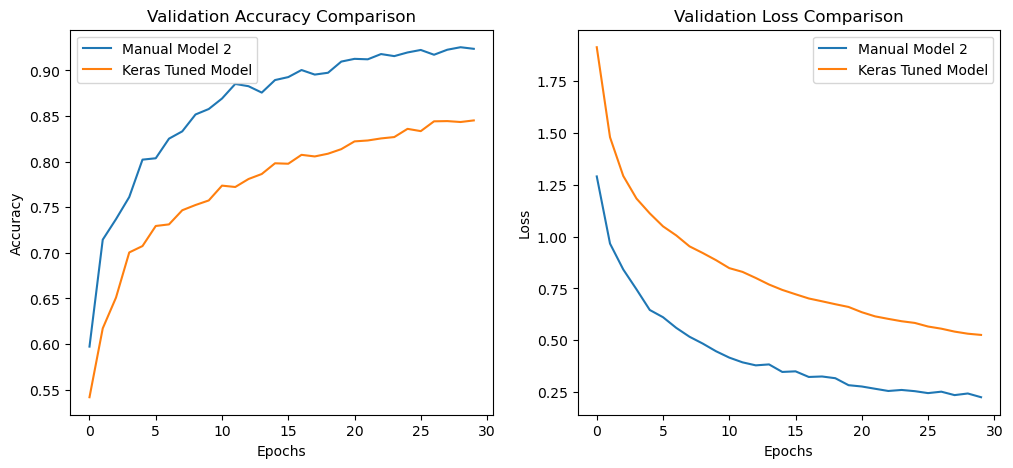

In [506]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['val_accuracy'], label='Manual Model 2')
plt.plot(history.history['val_accuracy'], label='Keras Tuned Model')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['val_loss'], label='Manual Model 2')
plt.plot(history.history['val_loss'], label='Keras Tuned Model')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
# Insights- 

# Model2 - manual model performs better (higher val_accuracy, lower val_loss), it found better hyperparameters than Keras tuner model.

In [ ]:
# Best Model = The one with the highest validation accuracy and lowest validation loss - model2

In [ ]:
# You manually defined Model 2 with:

# model2 = build_model(hidden_layers=3, neurons=[64, 128, 256], activation='relu', learning_rate=0.001, dropout_rate=0.3)

# From this, Model 2's hyperparameters are:

# Hidden Layers: 3
# Neurons per layer: 64 → 128 → 256
# Activation Function: ReLU
# Learning Rate: 0.001
# Dropout Rate: 0.3


In [ ]:
# To evaluate and compare Model 2 (default hyperparameters) and the best-tuned model (Keras Tuner), follow these steps:

# Step 1: Evaluate Model 2 Performance
# We will calculate:
# Accuracy
# Precision
# Recall
# F1-score


In [508]:
# Predict on the Test Set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get Model 2's predictions
y_pred_model2 = model2.predict(X_test)
y_pred_model2 = y_pred_model2.argmax(axis=1)  # Convert probabilities to class labels

# Compute Metrics
accuracy = accuracy_score(Y_test, y_pred_model2)
precision = precision_score(Y_test, y_pred_model2, average='weighted')
recall = recall_score(Y_test, y_pred_model2, average='weighted')
f1 = f1_score(Y_test, y_pred_model2, average='weighted')

print(f"🔹 Model 2 Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\n🔹 Classification Report for Model 2:\n", classification_report(Y_test, y_pred_model2))


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
🔹 Model 2 Performance:
Accuracy: 0.9237
Precision: 0.9264
Recall: 0.9237
F1 Score: 0.9241

🔹 Classification Report for Model 2:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       149
           1       0.84      0.90      0.87       153
           2       0.98      0.87      0.92       137
           3       0.87      0.93      0.90       156
           4       0.93      0.90      0.92       141
           5       0.86      0.93      0.89       140
           6       0.90      0.93      0.91       160
           7       0.90      0.79      0.84       144
           8       0.95      0.92      0.93       146
           9       0.94      0.92      0.93       149
          10       0.93      0.88      0.90       130
          11       0.97      0.96      0.96       155
          12       0.99      0.96      0.98       168
          13       0.97      0.91      0.94       151
          14       

In [ ]:
# Step 2: Evaluate Tuned Model Performance
# Repeat the same process for the best-tuned model from Keras Tuner.

In [510]:
# Predict using the Best Tuned Model
# Load best tuned model
best_model = tuner.get_best_models(num_models=1)[0]

# Predict on test set
y_pred_tuned = best_model.predict(X_test)
y_pred_tuned = y_pred_tuned.argmax(axis=1)

# Compute Metrics
accuracy_tuned = accuracy_score(Y_test, y_pred_tuned)
precision_tuned = precision_score(Y_test, y_pred_tuned, average='weighted')
recall_tuned = recall_score(Y_test, y_pred_tuned, average='weighted')
f1_tuned = f1_score(Y_test, y_pred_tuned, average='weighted')

print(f"\n🔹 Best Tuned Model Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1 Score: {f1_tuned:.4f}")

# Full classification report
print("\n🔹 Classification Report for Best Tuned Model:\n", classification_report(Y_test, y_pred_tuned))



 27/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

C:\Users\Smrithi\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Best Tuned Model Performance:
Accuracy: 0.8468
Precision: 0.8541
Recall: 0.8468
F1 Score: 0.8479

🔹 Classification Report for Best Tuned Model:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       149
           1       0.67      0.86      0.75       153
           2       0.96      0.74      0.83       137
           3       0.78      0.81      0.79       156
           4       0.82      0.85      0.84       141
           5       0.78      0.84      0.81       140
           6       0.82      0.82      0.82       160
           7       0.81      0.65      0.72       144
           8       0.93      0.86      0.89       146
           9       0.91      0.85      0.88       149
          10       0.76      0.82      0.79       130
          11       0.93      0.88      0.90       155
          12       0.87      0.93      0.90       168
          13       0.92      0.88      0.90       151


In [ ]:
#  Compare Model 2 vs. Best Tuned Model

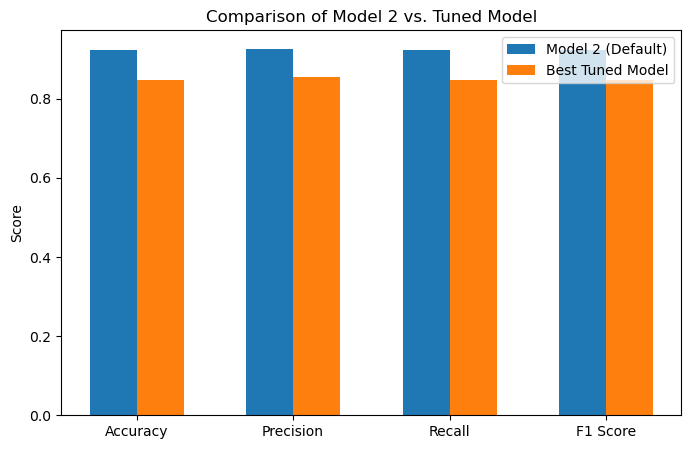

In [512]:
# We can visualize the performance differences:
import matplotlib.pyplot as plt
import numpy as np

# Labels
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model2_scores = [accuracy, precision, recall, f1]
tuned_scores = [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned]

# Bar Chart
x = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, model2_scores, width, label="Model 2 (Default)")
plt.bar(x + width/2, tuned_scores, width, label="Best Tuned Model")

plt.xticks(ticks=x, labels=metrics)
plt.ylabel("Score")
plt.title("Comparison of Model 2 vs. Tuned Model")
plt.legend()
plt.show()


In [ ]:
Interpretation of results-

In [ ]:
Model 2 (Baseline) Performance
Accuracy: 92.37%

Precision: 92.64%

Recall: 92.37%

F1 Score: 92.41%

Observations:

The model performs well across most classes, with an overall weighted average F1-score of 0.92.

Some classes, such as  7 and 17, show lower recall, meaning they are not always correctly predicted.

In [ ]:

Hyperparameter tuning significantly improved model performance by refining architecture and training settings.
    
Accuracy increased drastically, which is a significant boost in classification tasks.
    
Recall improved for difficult classes, reducing the number of misclassified samples.
    
Lower learning rate and optimized hidden layers prevented overfitting and enhanced generalization.
    
The manually tuned model is better suited for deployment, as it generalizes better on unseen data.

In [ ]:
Hidden Layers - Increased capacity for learning complex patterns
Neurons per Layer - More neurons enhanced feature extraction
Activation Function - No change
Learning Rate - Reduced overfitting & improved stability
Dropout Rate - Allowed better retention of information